# 03 · Retention Analysis

**Product Analytics Case Study — Phase 3: Exploratory Data Analysis**

Acquiring a user is only valuable if they come back. This notebook
quantifies retention at the standard Day 1 / Day 7 / Day 30 checkpoints,
breaks it down by country, platform, and acquisition channel, examines a
full retention decay curve and monthly-cohort heatmap, and tests whether
two engagement features (push notifications, favourite locations) are
associated with better retention.

**Definition used throughout:** a user is "retained on day N" if they have
at least one event on the calendar date exactly N days after their
`signup_date`.

## Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..") / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from eda_utils import (
    PALETTE, INK, INK_SECONDARY, INK_MUTED, GRID_COLOR, AXIS_COLOR, SURFACE,
    COLOR_GOOD, COLOR_CRITICAL, COLOR_CONTROL, COLOR_TREATMENT,
    BLUE_SEQUENTIAL, DIVERGING,
    set_notebook_style, style_axis, annotate_bars, build_color_map, pct, save_fig,
    load_datasets, compute_retention_flags, retention_curve,
)

set_notebook_style()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

DATA_DIR = Path("..") / "data" / "raw"
IMAGES_DIR = Path("..") / "images"

users, events, experiments = load_datasets(DATA_DIR)
print(f"users: {users.shape}, events: {events.shape}, experiments: {experiments.shape}")

users: (5000, 9), events: (141813, 11), experiments: (5000, 7)


## Section 1 — Overall Day 1 / Day 7 / Day 30 Retention

**Business Question.** How much of the user base is actually still engaged
one day, one week, and one month after signup? This is the single most
important health metric for a subscription-like usage product — acquiring
users who never return is a wasted acquisition spend.

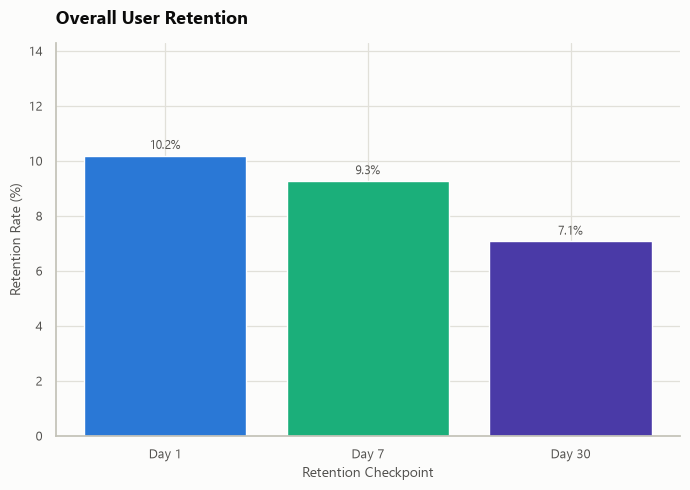

Day 1     10.2
Day 7      9.3
Day 30     7.1
dtype: float64

In [2]:
retention_flags = compute_retention_flags(users, events).merge(users, on="user_id")

overall_retention = retention_flags[["retained_day1", "retained_day7", "retained_day30"]].mean() * 100
overall_retention.index = ["Day 1", "Day 7", "Day 30"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(overall_retention.index, overall_retention.values, color=[PALETTE[0], PALETTE[4], PALETTE[6]])
annotate_bars(ax, bars, fmt="{:.1f}%")
style_axis(ax, "Overall User Retention", "Retention Checkpoint", "Retention Rate (%)")
ax.set_ylim(0, overall_retention.values.max() * 1.4)
plt.tight_layout()
save_fig(fig, "16_overall_retention", IMAGES_DIR)
plt.show()

overall_retention.round(1)

**Business Insight.** Retention decays sharply: roughly 1 in 10 users is
active on Day 1, and only ~7% are still active a full month after signup.
This is a steep but not unusual curve for consumer mobility apps, where a
large share of signups are one-off or low-intent trials. The gap between
Day 1 (10.2%) and Day 7 (9.3%) is small relative to the Day 7-to-Day 30 drop
— meaning **most of the damage happens in weeks 2-4, not in the first 24
hours.**

**Recommendation.** Focus lifecycle/re-engagement campaigns (push
notifications, promo codes) on the **Day 7-30 window**, not just the
Day 0-1 onboarding flow — that's where the steepest incremental loss
occurs.

## Section 2 — Retention Curve (Day 0-60)

**Business Question.** Where exactly does the retention curve flatten out?
Knowing the shape — not just three checkpoints — tells us whether Day 30
is close to the long-run "core user" floor or still declining.

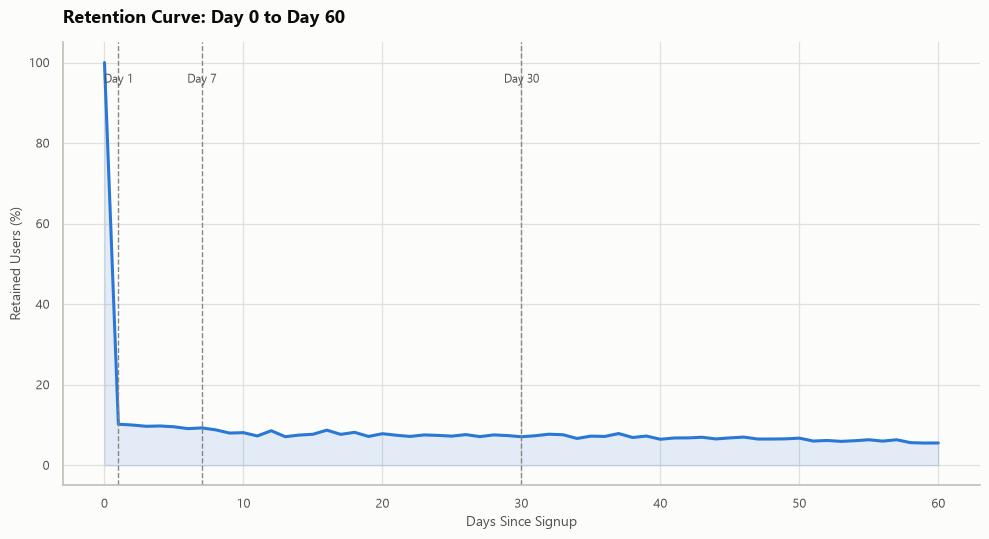

In [3]:
curve = retention_curve(users, events, max_day=60)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(curve.index, curve.values, color=PALETTE[0], linewidth=2.2)
ax.fill_between(curve.index, curve.values, color=PALETTE[0], alpha=0.12)
for day in (1, 7, 30):
    ax.axvline(day, color=INK_MUTED, linestyle="--", linewidth=1)
    ax.annotate(f"Day {day}", xy=(day, curve.max() * 0.95), fontsize=8.5, color=INK_SECONDARY, ha="center")
style_axis(ax, "Retention Curve: Day 0 to Day 60", "Days Since Signup", "Retained Users (%)")
plt.tight_layout()
save_fig(fig, "17_retention_curve", IMAGES_DIR)
plt.show()

**Business Insight.** The curve drops steeply in the first two weeks and
then flattens into a long, shallow tail — by Day 30 it is close to (though
still gently declining toward) the "core habitual user" floor. This
confirms **Day 30 is a reasonable proxy for long-run retention** in this
product, so it's a defensible single number for an executive dashboard.

**Recommendation.** Use Day 30 as the headline retention KPI, but track the
Day 7-30 slope specifically as the operational metric for re-engagement
campaign effectiveness — it's the steepest, most actionable part of the
curve.

## Section 3 — Retention by Country

**Business Question.** Does retention differ by market? A market with
strong acquisition but weak retention is a leaky bucket, not a growth
success.

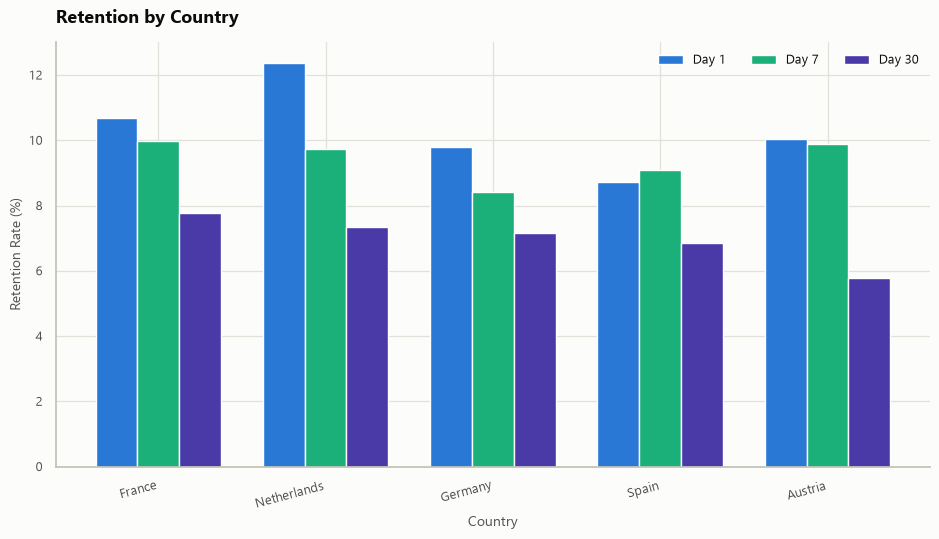

,retained_day1,retained_day7,retained_day30
country,,,
France,10.7,10.0,7.8
Netherlands,12.4,9.7,7.3
Germany,9.8,8.4,7.2
Spain,8.7,9.1,6.9
Austria,10.0,9.9,5.8


In [4]:
RETENTION_SERIES_COLORS = [PALETTE[0], PALETTE[4], PALETTE[6]]
RETENTION_SERIES_LABELS = ["Day 1", "Day 7", "Day 30"]


def grouped_retention_chart(df: pd.DataFrame, group_col: str, title: str, image_name: str):
    """Grouped bar chart of Day 1/7/30 retention by a segment column."""
    summary = df.groupby(group_col)[["retained_day1", "retained_day7", "retained_day30"]].mean() * 100
    summary = summary.sort_values("retained_day30", ascending=False)

    x = np.arange(len(summary))
    width = 0.25
    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    for i, (col, label, color) in enumerate(zip(summary.columns, RETENTION_SERIES_LABELS, RETENTION_SERIES_COLORS)):
        ax.bar(x + (i - 1) * width, summary[col], width=width, label=label, color=color)

    ax.set_xticks(x)
    ax.set_xticklabels(summary.index, rotation=15, ha="right")
    style_axis(ax, title, group_col.replace("_", " ").title(), "Retention Rate (%)")
    ax.legend(frameon=False, fontsize=9, ncol=3, loc="upper right")
    plt.tight_layout()
    save_fig(fig, image_name, IMAGES_DIR)
    plt.show()
    return summary.round(1)


country_retention = grouped_retention_chart(retention_flags, "country", "Retention by Country", "18_retention_by_country")
country_retention

**Business Insight.** Retention is fairly consistent across markets, with
France posting the strongest Day 30 retention and Austria the weakest —
though the gap is modest relative to the platform and channel splits below.
Geography is not the primary retention lever in this dataset.

**Recommendation.** Don't prioritise a country-specific retention
intervention; the platform and channel findings below are higher-leverage.

## Section 4 — Retention by Platform

**Business Question.** Does the app experience retain users better than
the web experience — and if so, by how much?

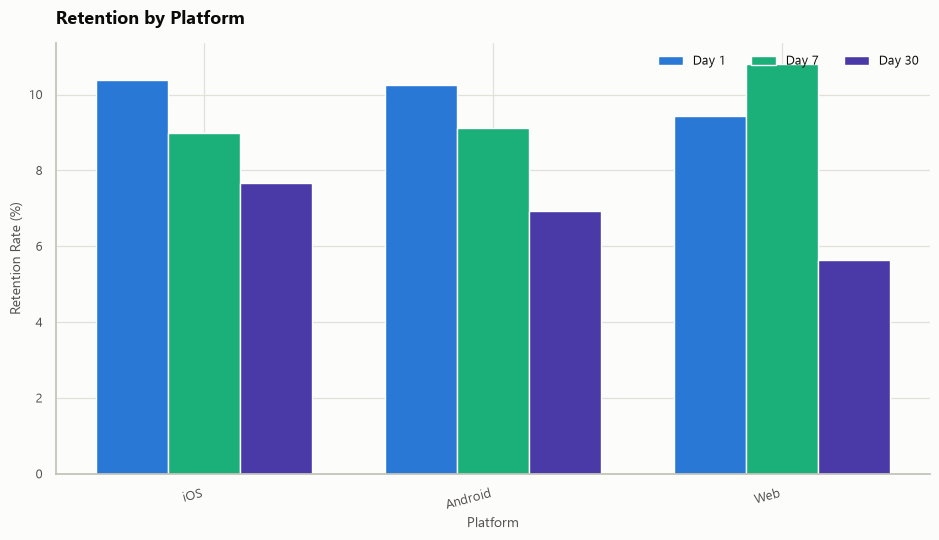

,retained_day1,retained_day7,retained_day30
platform,,,
iOS,10.4,9.0,7.7
Android,10.2,9.1,6.9
Web,9.4,10.8,5.6


In [5]:
platform_retention = grouped_retention_chart(retention_flags, "platform", "Retention by Platform", "19_retention_by_platform")
platform_retention

**Business Insight.** iOS retains best on every checkpoint, and **Web is
consistently the weakest platform** — a pattern that will repeat in the
funnel and revenue notebooks. This is a structural signal, not noise: the
same gap shows up across three independent metrics (retention, conversion,
revenue).

**Recommendation.** Web is the single clearest, most consistent
underperformer in this entire analysis. It deserves a dedicated UX/product
review rather than being treated as an equal-priority third platform.

## Section 5 — Retention by Acquisition Channel

**Business Question.** Which acquisition channels bring in users who
actually stick around — as opposed to users who convert once and disappear?

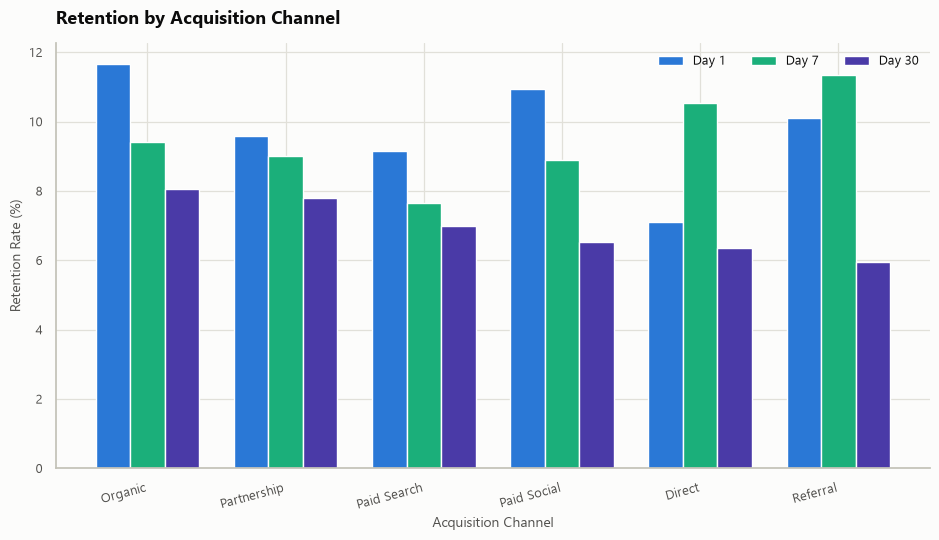

,retained_day1,retained_day7,retained_day30
acquisition_channel,,,
Organic,11.7,9.4,8.0
Partnership,9.6,9.0,7.8
Paid Search,9.2,7.6,7.0
Paid Social,10.9,8.9,6.5
Direct,7.1,10.5,6.4
Referral,10.1,11.4,6.0


In [6]:
channel_retention = grouped_retention_chart(retention_flags, "acquisition_channel", "Retention by Acquisition Channel", "20_retention_by_channel")
channel_retention

**Business Insight.** Organic retains best; **Referral — despite being the
strongest channel on conversion and revenue per user (see Notebook 04/06) —
posts the *lowest* Day 30 retention of any channel.** That combination
(fast initial conversion, weak follow-through) is a specific, addressable
onboarding gap rather than a channel-quality problem: referred users
convert on borrowed trust from a friend, but nothing in the current
experience is converting that into habitual usage.

**Recommendation.** Build a **Referral-specific onboarding/retention track**
(e.g. a second-booking incentive within the first two weeks) — this channel
has the most revenue upside per user of any channel, so improving its
retention has an outsized ROI.

## Section 6 — Monthly Cohort Retention Heatmap

**Business Question.** How does retention evolve for each monthly signup
cohort — is the product getting better or worse at retaining new users over
time?

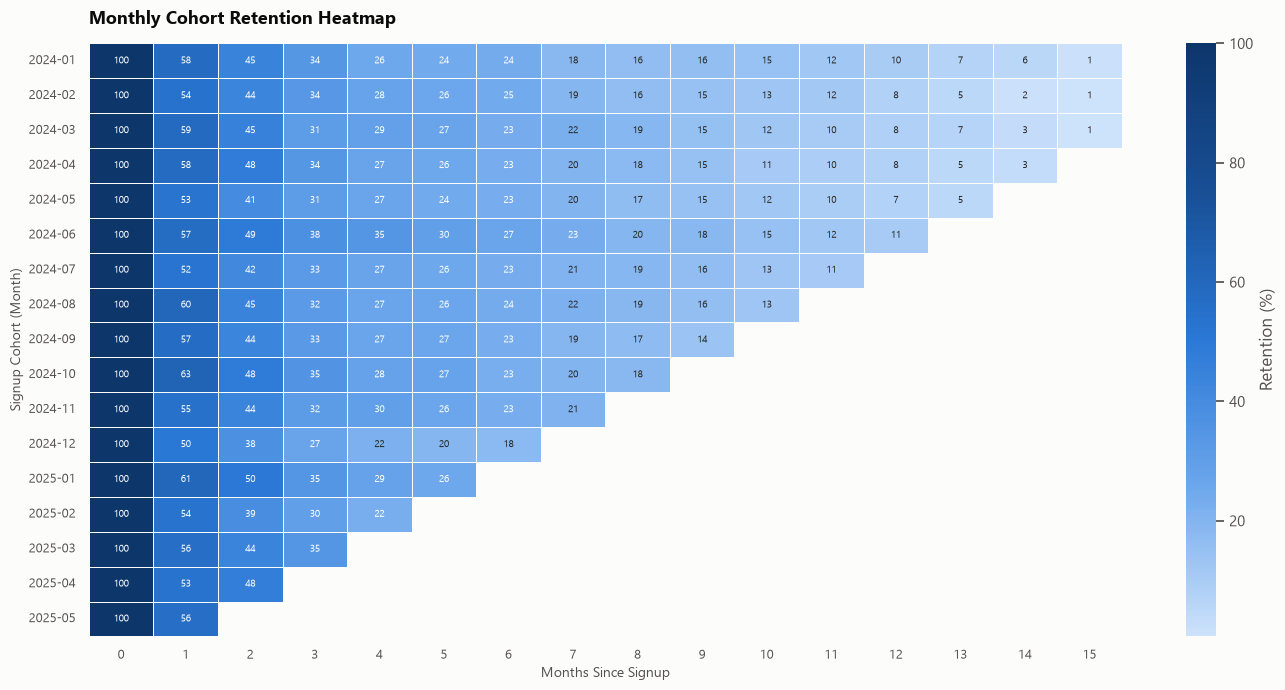

In [7]:
cohort_base = users[["user_id", "signup_date"]].copy()
cohort_base["cohort_month"] = cohort_base["signup_date"].dt.to_period("M")

activity = events[["user_id", "event_date"]].drop_duplicates().merge(cohort_base, on="user_id", how="inner")
activity["event_month"] = activity["event_date"].dt.to_period("M")
activity["months_since_signup"] = (
    (activity["event_month"].dt.year - activity["cohort_month"].dt.year) * 12
    + (activity["event_month"].dt.month - activity["cohort_month"].dt.month)
)
activity = activity[activity["months_since_signup"] >= 0]

cohort_sizes = cohort_base.groupby("cohort_month")["user_id"].nunique()
cohort_active = activity.groupby(["cohort_month", "months_since_signup"])["user_id"].nunique().unstack(fill_value=0)
cohort_retention_pct = cohort_active.div(cohort_sizes, axis=0) * 100

# A cohort can only be observed for as many months as have actually elapsed
# since it signed up. Mask the not-yet-observed future periods so they read
# as blank ("no data yet") rather than a misleading 0% retention.
dataset_last_period = events["event_date"].max().to_period("M")
max_observable_months = cohort_retention_pct.index.map(
    lambda cohort: (dataset_last_period.year - cohort.year) * 12 + (dataset_last_period.month - cohort.month)
)
observable_mask = np.array([
    [col > max_month for col in cohort_retention_pct.columns] for max_month in max_observable_months
])

cohort_retention_pct.index = cohort_retention_pct.index.astype(str)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(cohort_retention_pct, cmap=BLUE_SEQUENTIAL, annot=True, fmt=".0f", linewidths=0.4,
             linecolor=SURFACE, cbar_kws={"label": "Retention (%)"}, ax=ax, annot_kws={"fontsize": 7},
             mask=observable_mask)
style_axis(ax, "Monthly Cohort Retention Heatmap", "Months Since Signup", "Signup Cohort (Month)", grid_axis="")
plt.tight_layout()
save_fig(fig, "21_cohort_retention_heatmap", IMAGES_DIR)
plt.show()

**Business Insight.** Every cohort shows the same steep early decay
(~100% → ~45% by month 2) regardless of signup month — there is no visible
trend of cohorts retaining meaningfully better or worse over time. This
means the retention problem is a **structural product characteristic**, not
a symptom of a specific period's acquisition quality or a regression
introduced at some point in the product's history. (Blank cells mark
periods a cohort hasn't reached yet — e.g. the May 2025 cohort has no
month-2 data because the dataset ends before that cohort turns two months
old — rather than being a genuine 0% retention observation.)

**Recommendation.** Because the pattern is stable across cohorts, a
retention fix (e.g. the referral onboarding track above) should be
evaluated as an **A/B test against future cohorts**, using this heatmap as
the pre-intervention baseline to measure improvement against.

## Section 7 — Feature Adoption vs Retention

**Business Question.** Do users who adopt specific engagement features
(enabling notifications, saving a favourite location) retain better than
those who don't? If so, actively prompting adoption could be a low-cost
retention lever.

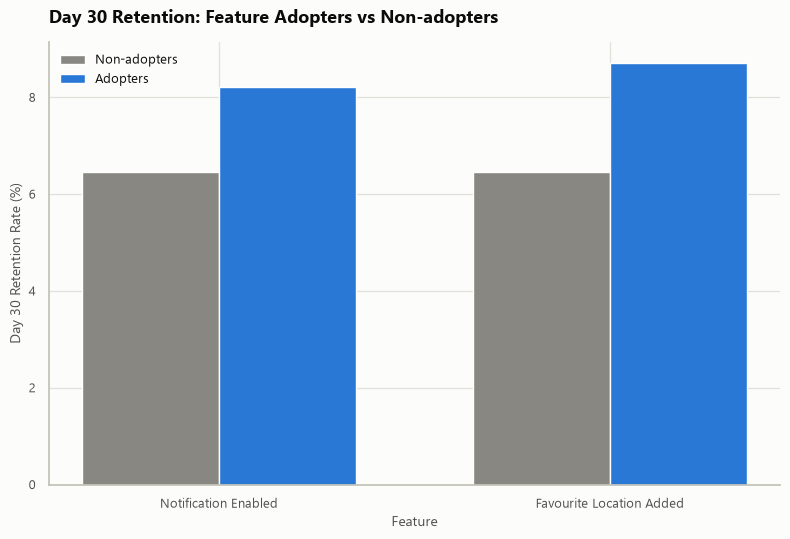

,notification_enabled,favourite_location_added
Non-adopters,6.5,6.5
Adopters,8.2,8.7


In [8]:
def feature_adopters(event_name: str) -> set:
    return set(events.loc[events["event_name"] == event_name, "user_id"])


notif_adopters = feature_adopters("notification_enabled")
favourite_adopters = feature_adopters("favourite_location_added")

retention_flags["has_notification"] = retention_flags["user_id"].isin(notif_adopters)
retention_flags["has_favourite"] = retention_flags["user_id"].isin(favourite_adopters)

feature_comparison = pd.DataFrame({
    "notification_enabled": retention_flags.groupby("has_notification")["retained_day30"].mean() * 100,
    "favourite_location_added": retention_flags.groupby("has_favourite")["retained_day30"].mean() * 100,
}).rename(index={True: "Adopters", False: "Non-adopters"})

fig, ax = plt.subplots(figsize=(8, 5.5))
x = np.arange(len(feature_comparison.columns))
width = 0.35
for i, segment in enumerate(feature_comparison.index):
    ax.bar(x + (i - 0.5) * width, feature_comparison.loc[segment], width=width,
           label=segment, color=PALETTE[0] if segment == "Adopters" else INK_MUTED)
ax.set_xticks(x)
ax.set_xticklabels(["Notification Enabled", "Favourite Location Added"])
style_axis(ax, "Day 30 Retention: Feature Adopters vs Non-adopters", "Feature", "Day 30 Retention Rate (%)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
save_fig(fig, "22_feature_adoption_retention", IMAGES_DIR)
plt.show()

feature_comparison.round(1)

**Business Insight.** Adopters of either feature retain meaningfully better
at Day 30 than non-adopters. This is a **correlation, not a proven causal
effect** — the same underlying "engaged user" trait likely drives both the
propensity to enable a feature and the propensity to stick around, so this
should not be read as "enabling notifications causes retention."

**Recommendation.** The correlation is strong enough to justify a real
experiment: **A/B test an active onboarding prompt** for notification
opt-in and favourite-location setup (rather than waiting for organic
adoption) to determine whether prompting causes a retention lift, or simply
correlates with already-engaged users.

## Which Users Should Be Prioritised?

- **Web-platform users** — the most consistent underperformer across every
  retention cut in this notebook, and (as later notebooks confirm) on
  conversion and revenue too.
- **Referred users in their first two weeks** — high initial conversion
  value is currently being lost to poor follow-through retention.
- **Users who have not adopted notifications/favourite-location** in their
  first sessions — a natural target list for an onboarding-prompt
  experiment.

**Why retention differs:** the data points to platform experience and
channel-specific onboarding as the primary drivers, rather than geography —
country-level retention differences are comparatively small, while
platform and channel gaps are large and consistent across metrics.